# 5. Can we prove to Anand, one cause at a time, that his Rs 1.9 crore is right, and does Tuesday's finding survive the clean file?

**Week 1, Wednesday. Chapter 5 of 6.** Chapters 1 to 4 turned the export from the ERP, the enterprise resource planning system Finance books
orders in, into a clean file: 186 orders kept by the identity rule, one row per `order_id` with the
copy whose amount converts, 15 rows set aside with a reason each, one missing status kept and
flagged, and Q1 at Rs 1,90,00,000. That is the figure on the books, Finance's own record of Q1. This
chapter proves it to Anand one cause at a time and recomputes Tuesday's finding on the clean file.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer, the finance controller, wants a proof his analyst can follow, since she ties out every
figure, matching it to the books line by line so that a rupee's difference is a finding. Marketing's
rescue campaign for Retail-Plus, Kalpa's paid membership tier, waits on whether Tuesday's finding
survives: on the export as delivered, Retail-Plus orders per customer fell 49 percent from Q1 to Q2,
from 2.32 to 1.18. A proof Finance cannot follow costs his trust, and a finding nobody recomputes
sends Marketing after a fall that is smaller than reported.

**The questions on the way.**

1. How could we prove which figure is right, and what does each proof cost?
2. Which moves walk Rs 2.1 crore down to the books?
3. Does Tuesday's finding survive the clean file?
4. Should the largest Q2 order come out?
5. What does the note to Anand say first?
6. Does a bottom-up sum reach the same Q1?

**The need.** Anand asked which Q1 figure is right and how the team knows, so the proof has to
account for every rupee between the dashboard's Rs 2,09,98,210 and the books. Revenue in every
figure here is booked value, every order at the price charged, whatever its status. The metrics are
Q1 revenue to the rupee, the Q1 to Q2 change in revenue and Retail-Plus orders per customer.

**Who else faces it.** In September 2014 Tesco said it had overstated its half-year profit guidance by about GBP 250 million, mainly by booking supplier income, the money its suppliers pay it, in a period before the activity that money paid for took place. Its own investigation then confirmed the figure at GBP 263 million, split by period: GBP 118 million in the first half, about GBP 70 million in 2013/14 and about GBP 75 million before (BBC News, 22 September 2014; Tesco interim results, 23 October 2014; both checked 30 Sep 2026). Tesco faced Anand's question: which figure is right, and what the gap is made of.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell loads the shared helper `kit` and the pass so far, the chain of steps that turns
the raw export into the clean file, as one function, `clean_pass()`: the identity rule first, then
conversion with a rejects log for any amount that fails, then a flags log for records kept with a
question on them. The notebook starts from the clean file and its logs: the set-aside log of rows
the rule removed, the rejects log and the flags log.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

def clean_pass(raw):
    """The day's pass: the identity rule, then conversion with a rejects log, then flags."""
    kept, set_aside = identity_rule(raw)
    clean, rejects, flags = [], [], []
    for r in kept:
        value, reason = convert(r["amount"])
        if value is None:
            rejects.append({"line": r["line"], "order_id": r["order_id"], "field": "amount",
                            "value": r["amount"], "reason": reason})
            continue
        if not r["status"]:
            flags.append({"line": r["line"], "order_id": r["order_id"], "field": "status",
                          "decision": "keep and flag", "why": "booked revenue; its fate is unknown"})
        clean.append(dict(r, amount=value))
    q2 = [r for r in clean if r["quarter"] == "Q2"]
    top = max(q2, key=lambda r: r["amount"])
    flags.append({"line": top["line"], "order_id": top["order_id"], "field": "amount",
                  "decision": "keep and flag", "why": "the largest Q2 order, a real Business account; shown both ways"})
    return clean, set_aside, rejects, flags

def per_customer(rows, quarter, segment):
    rs = [r for r in rows if r["quarter"] == quarter and r["segment"] == segment]
    return len(rs) / len({r["customer_id"] for r in rs})

raw = read_orders()
clean, set_aside, rejects, flags = clean_pass(raw)
print(len(clean), "orders;", len(set_aside), "set aside;", len(flags), "flagged")

186 orders; 15 set aside; 2 flagged


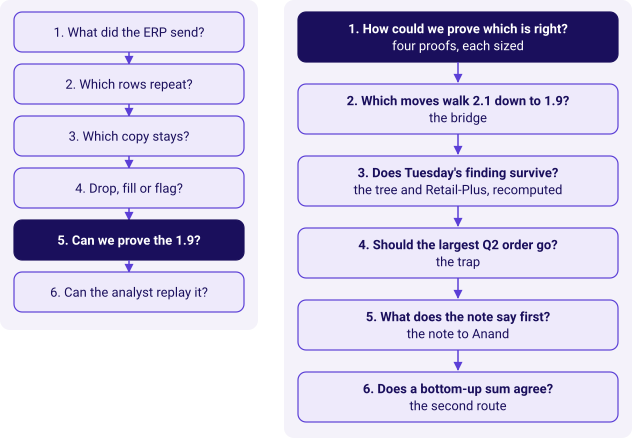

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=4, show=False),
    kit.vflow(["1. How could we prove which is right?\nfour proofs, each sized", "2. Which moves walk 2.1 down to 1.9?\nthe bridge", "3. Does Tuesday's finding survive?\nthe tree and Retail-Plus, recomputed", "4. Should the largest Q2 order go?\nthe trap", "5. What does the note say first?\nthe note to Anand", "6. Does a bottom-up sum agree?\nthe second route"], lit=0, show=False),
)

## 1. How could we prove which figure is right, and what does each proof cost?

A team has four ways to prove a figure. One is a bridge, which walks from one figure to the other in
moves, each move one cause with its rupees. Another rebuilds Q1 from the app's JSON feed, a file of
orders written as JSON records that the ERP sent beside the CSV.

| Option | What it offers Anand | What it leaves open |
|---|---|---|
| a) Take the books' figure | Finance's number, adopted | why the dashboard differs; Tuesday unchecked |
| b) The difference of the totals | Rs 19,98,210, one subtraction | what the difference is made of |
| c) A bridge, one move per cause | every rupee of the gap, each move backed by logged rows | nothing, if it closes |
| d) Rebuild Q1 from the JSON feed | a second source's total | the feed stops at record 120 |

option,rows behind it,closes to the books,says why
a) the books' figure,0,no,no
b) the difference,2 totals,"yes, as a total",no
c) a bridge by cause,15 logged rows,"yes, to the rupee",yes
d) rebuild from the feed,"119 records, Q2 barely covered","-Rs 1,790 off",no


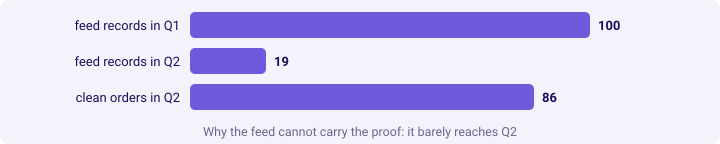

In [3]:
text = (DATA / "C2_W01_D03_orders_STUDENT.json").read_text(encoding="utf-8")
decoder, feed, at = json.JSONDecoder(), [], text.index("{")
while True:
    try:
        record, end = decoder.raw_decode(text, at)
    except json.JSONDecodeError:
        break
    feed.append(record)
    at = text.find("{", end)
    if at == -1:
        break
feed_q1 = sum(convert(r.get("amount"))[0] or 0 for r in feed if r["quarter"] == "Q1")
sizing = [("a) the books' figure", "0", "no", "no"),
          ("b) the difference", "2 totals", "yes, as a total", "no"),
          ("c) a bridge by cause", f"{len(set_aside)} logged rows", "yes, to the rupee", "yes"),
          ("d) rebuild from the feed", f"{len(feed)} records, Q2 barely covered", kit.rupees(feed_q1 - BOOKS_Q1) + " off", "no")]
kit.table(["option", "rows behind it", "closes to the books", "says why"], sizing, caption="Each proof sized on this export")
kit.bars([("feed records in Q1", sum(1 for r in feed if r["quarter"] == "Q1")),
          ("feed records in Q2", sum(1 for r in feed if r["quarter"] == "Q2")),
          ("clean orders in Q2", sum(1 for r in clean if r["quarter"] == "Q2"))],
         title="Why the feed cannot carry the proof: it barely reaches Q2")

**The best-fit call: c.** A bridge closes to the rupee and every move is a row in the log, so Anand's
analyst can test each one. The feed is short by Rs 1,790 in Q1 because it carries the same
unreadable amount, and it holds 19 of Q2's 86 orders. **The fact that would change it:** a second
source that is independent of the export and complete for the quarter. A rebuild from it would
prove the figure on its own, and the bridge would become its check; this feed is neither, since it
was cut from the same extract, the same pull of rows out of the ERP, and stops at record 120.

## 2. Which moves walk Rs 2.1 crore down to the books?

**Predict before you run.** How many moves does the bridge need to land on the books? a) one, the
copies; b) two, the corporate copies and the consumer copies; c) three, adding the unreadable
amount; d) none, since 2.1 rounds close enough.

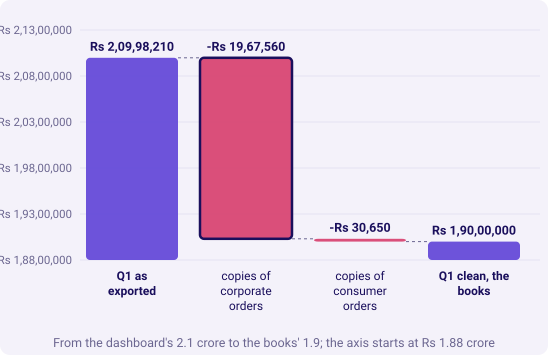

In [4]:
exported_q1 = Q(raw, "Q1")
q1_aside = [e for e in set_aside if e["quarter"] == "Q1"]
corporate = -sum(convert(e["amount"])[0] or 0 for e in q1_aside if e["segment"] == "Business")
consumer = -sum(convert(e["amount"])[0] or 0 for e in q1_aside if e["segment"] != "Business")
kit.bridge(("Q1 as exported", exported_q1),
           [("copies of corporate orders", corporate), ("copies of consumer orders", consumer)],
           end_label="Q1 clean, the books", lit=(0,), lo=18800000,
           title="From the dashboard's 2.1 crore to the books' 1.9; the axis starts at Rs 1.88 crore")
kit.check("the bridge lands on the books", exported_q1 + corporate + consumer == BOOKS_Q1)
kit.check("the rows reconcile: in equals kept plus set aside", len(raw) == len(clean) + len(set_aside) + len(rejects))

**What happened.** The answer is b. Copies of two corporate orders carry Rs 19,67,560 and copies of
consumer orders Rs 30,650, and the bridge lands on Rs 1,90,00,000. The unreadable amount needs no
move: it was never in the exported total, and its twin, the other copy of the same order, was in the
total and stayed.

## 3. Does Tuesday's finding survive the clean file?

Tuesday read the change from Q1 to Q2 off Monday's revenue tree: revenue = customers x orders per
customer x revenue per order, with each branch read as Q2's multiple of Q1. On the export as
delivered it read customers x1.000, orders per customer x0.754 (1.65 to 1.25), revenue per order
x1.180 and revenue x0.890, a fall of 11.0 percent. Tuesday then told the leadership group that
Retail-Plus orders per customer fell 49 percent, 2.32 to 1.18. The copies sat in Q1, so both
readings are recomputed on the clean file below, the tree first and then the segment.

**Predict before you run.** On clean data, the Retail-Plus finding: a) disappears; b) survives,
smaller; c) grows; d) moves to Retail-Core.

branch,Q1 clean,Q2 clean,"Q2 against Q1, clean",as Tuesday read it
customers,69,69,x1.000,x1.000
orders per customer,1.449,1.246,x0.860,x0.754
revenue per order,"Rs 1,90,000","Rs 2,17,442",x1.144,x1.180
revenue,"Rs 1,90,00,000","Rs 1,87,00,000",x0.984,x0.890


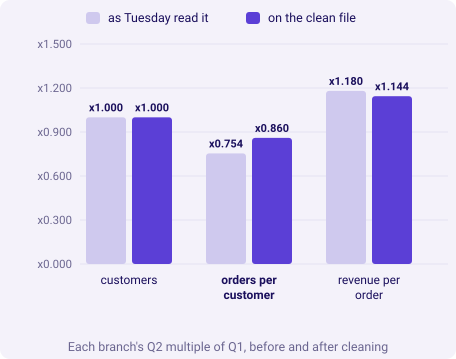

In [5]:
def tree(rows, q):
    """Monday's tree for one quarter: its three branches and the revenue they multiply to."""
    rs = [r for r in rows if r["quarter"] == q]
    customers = len({r["customer_id"] for r in rs})
    return {"customers": customers, "orders per customer": len(rs) / customers,
            "revenue per order": Q(rs, q) / len(rs), "revenue": Q(rs, q)}

t1, t2 = tree(clean, "Q1"), tree(clean, "Q2")
tuesday_x = {"customers": 1.000, "orders per customer": 0.754, "revenue per order": 1.180, "revenue": 0.890}
clean_x = {k: t2[k] / t1[k] for k in t1}
show = {"customers": str, "orders per customer": lambda v: f"{v:.3f}",
        "revenue per order": lambda v: kit.rupees(round(v)), "revenue": kit.rupees}
kit.table(["branch", "Q1 clean", "Q2 clean", "Q2 against Q1, clean", "as Tuesday read it"],
          [(k, show[k](t1[k]), show[k](t2[k]), f"x{clean_x[k]:.3f}", f"x{tuesday_x[k]:.3f}") for k in t1],
          caption="The revenue tree, Q1 to Q2, recomputed on the clean file")
branches = ["customers", "orders per customer", "revenue per order"]
kit.columns(branches, [("as Tuesday read it", [tuesday_x[k] for k in branches]),
                       ("on the clean file", [clean_x[k] for k in branches])],
            fmt=lambda v: f"x{v:.3f}", lit=(1,), title="Each branch's Q2 multiple of Q1, before and after cleaning")
product = clean_x["customers"] * clean_x["orders per customer"] * clean_x["revenue per order"]
shift = {k: abs(clean_x[k] - tuesday_x[k]) for k in branches}
kit.check("the three branches multiply back to revenue", abs(product - clean_x["revenue"]) < 1e-9, f"x{product:.3f}")
kit.check("customers do not move: the same 69 bought in both quarters", t1["customers"] == t2["customers"] == 69)
kit.check("orders per customer moves furthest from Tuesday's reading", max(shift, key=shift.get) == "orders per customer")
kit.check("the revenue drop shrinks to under 2 percent", 1 - clean_x["revenue"] < 0.02, f"{1 - clean_x['revenue']:.1%}")

On the clean file, customers stay at 69 in both quarters. Orders per customer move from 1.449 to
1.246, x0.860 against the x0.754 Tuesday read, because the copies were Q1 orders; revenue per order
moves x1.144 instead of x1.180; and revenue x0.984, a fall of 1.6 percent instead of 11.0. The tree
still points at frequency, orders per customer, and the fall it points at is about 14 percent
instead of 25. The segment Tuesday named is next.

segment,as Tuesday reported,clean Q1,clean Q2,clean change
Retail-Core,-5.3%,1.09,1.06,-2.7%
Retail-Plus,-49.0%,1.82,1.18,-35.0%
Business,-15.0%,1.64,1.55,-5.6%
Student,+40.0%,2.5,3.5,+40.0%


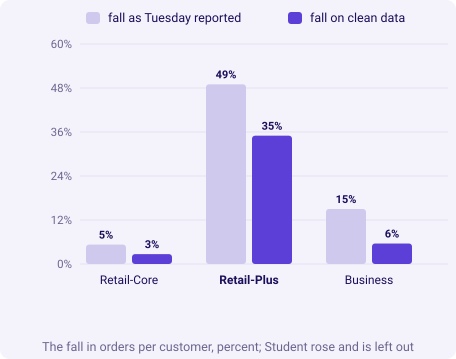

In [6]:
segs = ["Retail-Core", "Retail-Plus", "Business", "Student"]
tuesday = {"Retail-Core": -5.3, "Retail-Plus": -49.0, "Business": -15.0, "Student": 40.0}
cleaned = {s: round(100 * (per_customer(clean, "Q2", s) / per_customer(clean, "Q1", s) - 1), 1) for s in segs}
kit.table(["segment", "as Tuesday reported", "clean Q1", "clean Q2", "clean change"],
          [(s, f"{tuesday[s]:+.1f}%", round(per_customer(clean, "Q1", s), 2), round(per_customer(clean, "Q2", s), 2),
            f"{cleaned[s]:+.1f}%") for s in segs], caption="Orders per customer, Q1 to Q2")
kit.columns(segs[:3], [("fall as Tuesday reported", [-tuesday[s] for s in segs[:3]]), ("fall on clean data", [-cleaned[s] for s in segs[:3]])],
            fmt=lambda v: f"{v:.0f}%", lit=(1,), title="The fall in orders per customer, percent; Student rose and is left out")
kit.check("Retail-Plus still falls on clean data", cleaned["Retail-Plus"] < -30, f"{cleaned['Retail-Plus']:+.1f}%")
kit.check("the Retail-Plus fall is smaller than Tuesday reported", cleaned["Retail-Plus"] > tuesday["Retail-Plus"])

**What happened.** The answer is b. Retail-Plus orders per customer fall 35.0 percent on clean data,
1.82 to 1.18, against the 49 Tuesday reported, so Tuesday's finding survives, smaller, because most
copies sat in Retail-Plus in Q1. With the tree's 1.6 percent in place of 11.0, both go in the note,
the smaller numbers first.

## 4. Should the largest Q2 order come out?

**The plausible wrong answer.** Sorted as numbers, Q2's largest order sits far above the rest, 1.66
times the next. A hurried analyst removes it "to be safe" and reports the quarter without it.

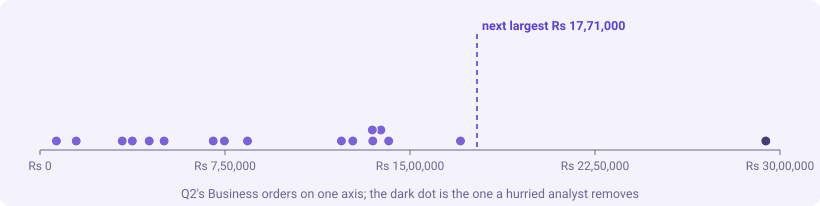

In [7]:
q2_orders = sorted((r for r in clean if r["quarter"] == "Q2"), key=lambda r: r["amount"], reverse=True)
top, runner_up = q2_orders[0], q2_orders[1]
q2_trimmed = Q(clean, "Q2") - top["amount"]
kit.stats([(kit.rupees(q2_trimmed), "Q2 without it", "the hurried figure"),
           (f"{1 - q2_trimmed / BOOKS_Q1:.1%}", "the drop", "Q1 1.90 crore to Q2 1.58 crore"),
           (f"{top['amount'] / runner_up['amount']:.2f}x", "the next largest", "why it looked wrong")])
kit.strip([r["amount"] for r in q2_orders if r["segment"] == "Business"], lit=[0], lo=0, hi=3000000,
          markers=[("next largest", runner_up["amount"], "plain")],
          title="Q2's Business orders on one axis; the dark dot is the one a hurried analyst removes")

**Why it is wrong.** Kalpa's Business segment, its sales to companies, sells in bulk to corporate
buyers, every order in lakhs, so a Business order at Rs 29 lakh is ordinary trade for that segment.
Removing it turns a 1.6 percent dip into a 17.1 percent collapse: Marketing would fund a rescue for a
fall that never happened, and Finance, whose books hold that order, would reject the reconciliation
on sight. A fence is a cut-off above which a hurried analyst calls values outliers; the simplest is a
multiple of the median, and the check below sizes one at three times the median Q2 order. The checks
that matter ask whether anything about the record is wrong, and its size is no evidence either way.

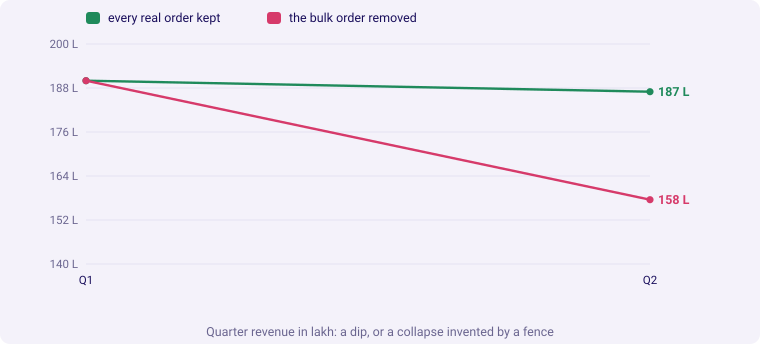

In [8]:
buyer_orders = [r for r in clean if r["customer_id"] == top["customer_id"]]
amounts_q2 = sorted(r["amount"] for r in q2_orders)
median_q2 = amounts_q2[len(amounts_q2) // 2]
fence_all = sum(1 for a in amounts_q2 if a > 3 * median_q2)    # a fence at three times the median
kit.check("the largest Q2 order is a Business order", top["segment"] == "Business")
kit.check("its customer ordered in both quarters", {r["quarter"] for r in buyer_orders} == {"Q1", "Q2"}, f"{len(buyer_orders)} orders")
kit.check("a fence on the whole quarter would flag every Business order", fence_all == sum(1 for r in q2_orders if r["segment"] == "Business"),
          f"{fence_all} flagged")
kit.line(["Q1", "Q2"], [("every real order kept", [Q(clean, "Q1") / 1e5, Q(clean, "Q2") / 1e5], "good"),
                        ("the bulk order removed", [Q(clean, "Q1") / 1e5, q2_trimmed / 1e5], "bad")],
         fmt=lambda v: f"{v:,.0f} L", lo=140, title="Quarter revenue in lakh: a dip, or a collapse invented by a fence")

**The fix, and what changed.** Keep it, flag it, and show Q2 both ways. Q2 goes back from
Rs 1,57,54,540 to Rs 1,87,00,000, and the drop from 17.1 percent to 1.6. A fence at three times the
median Q2 order flags all 17 Business orders, because the quarter mixes a Rs 2,000 basket with a
corporate order. A fence means something only inside one segment, and even there it raises a
question about a record for someone to answer.

## 5. What does the note to Anand say first?

**Predict before you run.** Which number leads the note? a) the 49 percent Tuesday reported, since
leadership has seen it; b) the 1.9 crore and why it is right; c) the Rs 29 lakh order; d) the
count of rows set aside.

The answer is b. Anand asked which figure is right, so the note opens on that, then gives the proof
and then what changed. It puts the numbers first and covers which figure is right and why, both
reconciliations, what was kept and flagged and whether Tuesday's finding survives, in under 120
words:

> "Anand, your 1.9 crore is right. The ERP export counted fifteen orders twice, fourteen of them in
> Q1; copies of two corporate orders carry Rs 19,67,560 of the Rs 19,98,210 difference. Rows
> reconcile, 201 received equals 186 kept plus 15 set aside, and rupees reconcile to your books
> exactly. Every row set aside and every decision is in the attached log. Kept and flagged: one Q2
> order with no status, and the largest Q2 order, a real Business account. On clean data the Q1 to
> Q2 drop is 1.6 percent, not 11, and the Retail-Plus frequency fall is 35 percent, not 49. It
> survives, smaller."

In [9]:
note = ("Anand, your 1.9 crore is right. The ERP export counted fifteen orders twice, fourteen of them in Q1; "
        "copies of two corporate orders carry Rs 19,67,560 of the Rs 19,98,210 difference. Rows reconcile, 201 "
        "received equals 186 kept plus 15 set aside, and rupees reconcile to your books exactly. Every row set "
        "aside and every decision is in the attached log. Kept and flagged: one Q2 order with no status, and "
        "the largest Q2 order, a real Business account. On clean data the Q1 to Q2 drop is 1.6 percent, not 11, "
        "and the Retail-Plus frequency fall is 35 percent, not 49. It survives, smaller.")
kit.check("the note is under 120 words", len(note.split()) < 120, f"{len(note.split())} words")

## 6. Does a bottom-up sum reach the same Q1?

The bridge worked top down, from the export less the moves. A second route sums the kept orders and
reaches Q1 from the bottom, and it counts each Retail-Plus customer's orders with a dictionary to
reach the same rate.

In [10]:
bottom_up = sum(r["amount"] for r in clean if r["quarter"] == "Q1")
by_customer = {}
for r in clean:
    if r["segment"] == "Retail-Plus":
        by_customer.setdefault((r["quarter"], r["customer_id"]), 0)
        by_customer[(r["quarter"], r["customer_id"])] += 1
mean_q = {q: sum(v for (qq, _), v in by_customer.items() if qq == q) / sum(1 for (qq, _) in by_customer if qq == q) for q in ("Q1", "Q2")}
kit.table(["number", "top down", "bottom up"],
          [("Q1", kit.rupees(exported_q1 + corporate + consumer), kit.rupees(bottom_up)),
           ("Retail-Plus orders per customer, Q1", round(per_customer(clean, "Q1", "Retail-Plus"), 2), round(mean_q["Q1"], 2)),
           ("Retail-Plus orders per customer, Q2", round(per_customer(clean, "Q2", "Retail-Plus"), 2), round(mean_q["Q2"], 2))])
kit.check("top down and bottom up agree on Q1", bottom_up == exported_q1 + corporate + consumer == BOOKS_Q1)
kit.check("both routes agree on the Retail-Plus rate", abs(mean_q["Q1"] - per_customer(clean, "Q1", "Retail-Plus")) < 1e-9)

number,top down,bottom up
Q1,"Rs 1,90,00,000","Rs 1,90,00,000"
"Retail-Plus orders per customer, Q1",1.82,1.82
"Retail-Plus orders per customer, Q2",1.18,1.18


**When to switch.** Bottom up is the check anyone can run; top down is the proof, since only the
bridge says what each rupee of the gap was.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "Show me two reconciliations, rows and rupees, and draw the bridge. Then tell
> me what changed in Tuesday's story, including where it got smaller."

### In the interview: when Finance and your dashboard disagree, how do you prove which is right, and does the largest order come out?

**[S] Finance and your dashboard disagree; what do you do?** "I assume both are correct arithmetic on
different inputs and find the difference. I get Finance's figure to the rupee and its definition,
profile my source, and build a bridge, one move per cause, each backed by the rows that carry it. I
reconcile in rows and in rupees. When it closes I say which is right and why, fix the source and
recompute anything reported from the wrong number."

**[S] The largest order is 1.66 times the next. Do you remove it?** "I sort, look at the tail, and
ask whether the record is wrong before asking whether it is big. A valid id, a real account with
orders in both quarters and fields that convert make it revenue. I keep it, flag it, and show the
result with and without it: removing it here turns a 1.6 percent dip into a 17.1 percent fall. For
a model trained on the data I might cap or transform a long tail, and any fence I use sits inside
one segment."

**[D] Design. Prove the figure with a bridge, or rebuild it from a second source?** "A bridge, when a
log backs each move, because it says why as well as how much. I would switch to a rebuild when the
second source is independent of the export and complete for the quarter, which this JSON feed is
not: it was cut from the same extract and holds 19 of Q2's 86 orders."

### Depth: what does a bridge look like when the gap has more than one kind of cause?

Today's bridge had one cause, copies, split by segment. A month-end bridge between a sales system and
the ledger usually carries several kinds of move: timing (an order booked on the last day of one
month and invoiced on the first of the next), definition (returns netted in one system and not the
other), and error (copies, typos). Each kind gets its own column, and a bridge that closes only
after an "other" column has not closed. Tesco split its GBP 263 million by period, so a reader could
see when each part arose; a bridge by kind of move does the same for why.

## So can we prove Anand's Rs 1.9 crore one cause at a time, and does Tuesday's finding survive?

1. The proof is a bridge by cause, 15 logged rows closing to the rupee; the books' figure alone says
   nothing, a difference of totals gives no reason, and the JSON feed misses by Rs 1,790.
2. Two moves walk Rs 2.1 crore down to the books: corporate copies, -Rs 19,67,560, and consumer
   copies, -Rs 30,650, landing on Rs 1,90,00,000.
3. Tuesday's finding survives, smaller: orders per customer go from 1.449 to 1.246, x0.860 against
   x0.754; revenue x0.984, -1.6 percent against -11.0; and Retail-Plus from 1.82 to 1.18, -35.0
   percent against -49.0.
4. The largest Q2 order stays in: it is a real Business order, and removing it reports Q2 at
   Rs 1,57,54,540 and a 17.1 percent drop, so it stays, flagged, and Q2 is Rs 1,87,00,000.
5. The note to Anand says first that his 1.9 crore is right, then gives the proof in rows and rupees,
   then what changed: 1.6 percent, not 11, and 35 percent, not 49.
6. A bottom-up sum reaches the same Q1: the kept Q1 orders sum to Rs 1,90,00,000.

Yes. Two moves, Rs 19,67,560 of corporate copies and Rs 30,650 of consumer copies, bridge
Rs 2,09,98,210 to Rs 1,90,00,000. On clean data revenue falls 1.6 percent, not 11.0, and Retail-Plus
orders per customer fall 35.0 percent, not 49.0, so Tuesday's finding survives, smaller.

In [11]:
kit.check_summary()
print("Next, chapter 6: can Anand's analyst audit every decision tonight and rebuild the clean file "
      "from the log alone?")

Next, chapter 6: can Anand's analyst audit every decision tonight and rebuild the clean file from the log alone?
